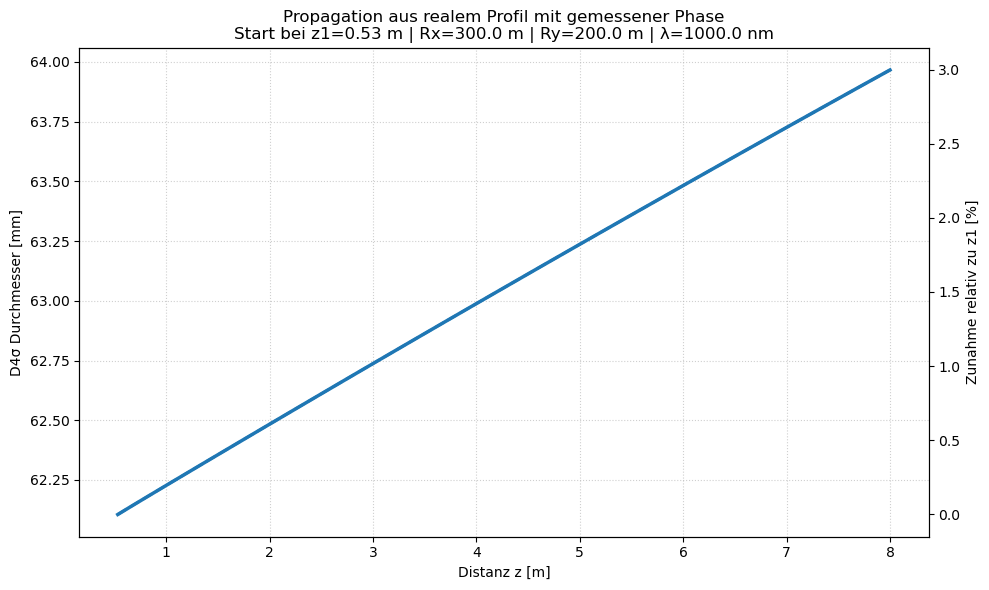

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os

# ==============================================================
# 0) SETTINGS (hier nur anpassen, Rest läuft)
# ==============================================================
LAM = 1000e-9         # [m] Wellenlänge
N   = 1024            # muss zum WCF passen
L   = 60e-3           # [m] Simulationsfenster
DX  = L / N

WCF_FILE = "BeamProfile1.wcf"

# Start-Ebene deiner Messung (ab hier propagieren)
Z1 = 0.53             # [m] erste Messung

# Gemessene (effektive) Wellenfront-Radien bei z=Z1
RX = 300.0            # [m]
RY = 200.0            # [m]

# Propagationsbereich ab Z1 weiter
Z_MAX   = 8.0         # [m]
Z_STEPS = 100

# Optional: wenn deine gemessenen Bilder "doppelt so groß" waren
# (dann ist dein effektives dx größer, z.B. DX*2). Für WCF-Simulation i.d.R. = 1.0 lassen.
DX_SCALE = 1.0

# ==============================================================
# 1) WCF READER (Single frame, simplified)
# ==============================================================

def extract_2d_profile_from_wcf(filename: str) -> np.ndarray:
    """Liest 2D-Profil aus WCF (vereinfachtes single-frame). Gibt Amplitude sqrt(I) zurück."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    FILE_HEADER  = 5592
    FRAME_HEADER = 944

    with open(filename, "rb") as fobj:
        fobj.seek(FILE_HEADER)
        _ = fobj.read(FRAME_HEADER)
        data = fobj.read(N * N * 2)
        frame = np.frombuffer(data, dtype=np.uint16).reshape((N, N)).astype(float)

    frame -= np.min(frame)
    frame[frame < 0] = 0.0
    frame /= np.max(frame) if np.max(frame) > 0 else 1.0

    return np.sqrt(frame).astype(np.complex128)

# ==============================================================
# 2) BEAM SIZE: D4σ separat in x/y + äquivalent
# ==============================================================

def d4sigma_xy_mm(I: np.ndarray, dx: float):
    """
    ISO-like second moment:
      Dx = 4 * sqrt(<(x-x0)^2>), Dy analog.
    Rückgabe in mm.
    """
    h, w = I.shape
    x = (np.arange(w) - w/2) * dx
    y = (np.arange(h) - h/2) * dx
    X, Y = np.meshgrid(x, y)

    total = np.sum(I)
    if total <= 0:
        return np.nan, np.nan, np.nan

    P = I / total
    x0 = np.sum(X * P)
    y0 = np.sum(Y * P)

    var_x = np.sum(P * (X - x0)**2)
    var_y = np.sum(P * (Y - y0)**2)

    Dx = 4.0 * np.sqrt(max(var_x, 0.0)) * 1e3  # mm
    Dy = 4.0 * np.sqrt(max(var_y, 0.0)) * 1e3  # mm

    # häufig genutzter äquivalenter Durchmesser:
    Deq = np.sqrt(Dx * Dy)
    return Dx, Dy, Deq

# ==============================================================
# 3) PHASE: gemessene Krümmung aufprägen
# ==============================================================

def apply_measured_curvature_phase(U_amp: np.ndarray, Rx: float, Ry: float, lam: float, dx: float):
    """
    Baut:
      U(x,y) = sqrt(I(x,y)) * exp( i * k/2 * (x^2/Rx + y^2/Ry) )
    Vorzeichen-Konvention:
      - Rx > 0: divergend hinter Waist (typischerweise)
      - Rx < 0: konvergent vor Waist (ist physikalisch möglich!)
    """
    k = 2*np.pi/lam
    coords = (np.arange(N) - N/2) * dx
    X, Y = np.meshgrid(coords, coords)

    term = np.zeros_like(X, dtype=np.float64)

    if np.isfinite(Rx) and abs(Rx) > 1e-12:
        term += (X**2) / Rx
    if np.isfinite(Ry) and abs(Ry) > 1e-12:
        term += (Y**2) / Ry

    return U_amp * np.exp(1j * k * 0.5 * term)

# ==============================================================
# 4) PROPAGATION: Angular Spectrum
# ==============================================================

def propagate_asm(U: np.ndarray, dz: float, lam: float, dx: float):
    if dz == 0:
        return U

    k = 2*np.pi/lam
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2*np.pi*FX
    ky = 2*np.pi*FY
    kz = np.sqrt((k+0j)**2 - kx**2 - ky**2)

    H = np.exp(1j * kz * dz)
    return np.fft.ifft2(np.fft.fft2(U) * H)

# ==============================================================
# 5) MAIN SIM
# ==============================================================

def main():
    dx_eff = DX * DX_SCALE

    # z-Achse ab Z1
    z_array = np.linspace(Z1, Z_MAX, Z_STEPS)
    dz_array = z_array - Z1

    # 1) Amplitude aus WCF
    U_amp = extract_2d_profile_from_wcf(WCF_FILE)

    # 2) Phase aus (Rx,Ry) aufprägen
    U0 = apply_measured_curvature_phase(U_amp, Rx=RX, Ry=RY, lam=LAM, dx=dx_eff)

    # 3) Propagation + Größen
    Dx_list, Dy_list, Deq_list = [], [], []
    for dz in dz_array:
        Uz = propagate_asm(U0, dz, lam=LAM, dx=dx_eff)
        I = np.abs(Uz)**2
        Dx, Dy, Deq = d4sigma_xy_mm(I, dx_eff)
        Dx_list.append(Dx)
        Dy_list.append(Dy)
        Deq_list.append(Deq)

    Dx_list = np.array(Dx_list)
    Dy_list = np.array(Dy_list)
    Deq_list = np.array(Deq_list)

    # relative Änderungen bezogen auf Start bei z=Z1
    Dx_pct  = (Dx_list  - Dx_list[0])  / Dx_list[0]  * 100.0
    Dy_pct  = (Dy_list  - Dy_list[0])  / Dy_list[0]  * 100.0
    Deq_pct = (Deq_list - Deq_list[0]) / Deq_list[0] * 100.0

    # ==========================================================
    # Plotting (übersichtlicher, farbig, getrennte Legenden)
    # ==========================================================
    fig, ax1 = plt.subplots(figsize=(11, 6))

    c_dx  = "tab:blue"
    c_dy  = "tab:green"
    c_deq = "tab:purple"
    c_pct = "tab:orange"

    # linke Achse: Durchmesser
    l1 = ax1.plot(z_array, Dx_list,  "-", lw=2.5, color=c_dx,  label="Dx (D4σ) [mm]")
    l2 = ax1.plot(z_array, Dy_list,  "-", lw=2.5, color=c_dy,  label="Dy (D4σ) [mm]")
    l3 = ax1.plot(z_array, Deq_list, "--", lw=2.5, color=c_deq, label="D_eq = sqrt(Dx·Dy) [mm]")

    ax1.set_xlabel("Distanz z [m]")
    ax1.set_ylabel("Strahldurchmesser D4σ [mm]")
    ax1.grid(True, linestyle=":", alpha=0.6)

    # rechte Achse: relative Änderung (nur äquivalent, sonst wird’s zu voll)
    ax2 = ax1.twinx()
    l4 = ax2.plot(z_array, Deq_pct, "-", lw=2.0, color=c_pct, label="Zunahme D_eq relativ zu z1 [%]")
    ax2.set_ylabel("Zunahme relativ zu z1 [%]", color=c_pct)
    ax2.tick_params(axis="y", colors=c_pct)

    # gemeinsame Legende
    lines = l1 + l2 + l3 + l4
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper left")

    title = (
        "Propagation aus realem Profil mit gemessener Krümmungsphase\n"
        f"Start z1={Z1:.2f} m | Rx={RX:.1f} m | Ry={RY:.1f} m | λ={LAM*1e9:.1f} nm | dx_eff={dx_eff*1e6:.1f} µm"
    )
    plt.title(title, pad=14)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
